# **SETUP REPRODUCIBILITY**

In [1]:
# ==================== IMPORT LIBRARIES ====================
import json
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import mobilenet_v2
from scipy import ndimage
from sklearn.model_selection import train_test_split
import pandas as pd
from glob import glob
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# ==================== SETUP REPRODUCIBILITY ====================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


# **KONFIGURASI**

In [3]:
# ==================== KONFIGURASI ====================
class Config:
    # Path dataset - sesuai dengan struktur folder HOLOGY 8.0
    TRAIN_IMAGE_DIR = "/kaggle/input/penyisihan-hology-8-0-2025-data-mining/train/images"
    TRAIN_LABEL_DIR = "/kaggle/input/penyisihan-hology-8-0-2025-data-mining/train/labels"
    TEST_IMAGE_DIR = "/kaggle/input/penyisihan-hology-8-0-2025-data-mining/test/images"
    
    # Preprocessing
    IMG_SIZE = (512, 512)
    GAUSSIAN_KERNEL_SIZE = 15
    ADAPTIVE_SIGMA = True
    
    # Augmentasi
    USE_AUGMENTATION = True
    BRIGHTNESS_RANGE = (0.8, 1.2)
    CONTRAST_RANGE = (0.8, 1.2)
    BLUR_PROBABILITY = 0.3
    FLIP_PROBABILITY = 0.5
    
    # Training
    BATCH_SIZE = 8
    LEARNING_RATE = 1e-3
    EPOCHS = 100
    PATIENCE = 15
    LOSS_LAMBDA = 0.8
    
    # Data split
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.2
    TEST_RATIO = 0.1
    
    # Model
    BACKBONE = "mobilenet_v2"
    PRETRAINED = True
    
    # Path output
    MODEL_SAVE_PATH = "/kaggle/working/crowd_counting_model.pth"
    DATAFRAME_PATH = "/kaggle/working/dataset_info.csv"
    RESULTS_DIR = "/kaggle/working/results"
    PREDICTIONS_CSV = "/kaggle/working/test_predictions.csv"
    FINAL_REPORT_PATH = "/kaggle/working/final_report.txt"

config = Config()

# Buat directory untuk hasil
os.makedirs(config.RESULTS_DIR, exist_ok=True)

# **DATASET LOAD & PREPROCESSING**

## **Preprocessing**

In [4]:
# ==================== DATASET PROCESSING ====================
def parse_points_from_json(json_data):
    """Parse points dari berbagai format JSON"""
    points = []
    
    # Format 1: {'human_num': X, 'points': [[x1, y1], [x2, y2], ...]}
    if 'points' in json_data and isinstance(json_data['points'], list):
        for point in json_data['points']:
            if isinstance(point, (list, tuple)) and len(point) >= 2:
                try:
                    x, y = float(point[0]), float(point[1])
                    points.append((x, y))
                except:
                    continue
    
    # Format 2: {'human_num': X, 'points': {'x': [x1, x2, ...], 'y': [y1, y2, ...]}}
    elif 'points' in json_data and isinstance(json_data['points'], dict):
        x_coords = json_data['points'].get('x', [])
        y_coords = json_data['points'].get('y', [])
        if len(x_coords) == len(y_coords):
            for x, y in zip(x_coords, y_coords):
                try:
                    points.append((float(x), float(y)))
                except:
                    continue
    
    return points

def get_human_count_from_json(json_data, points):
    """Dapatkan jumlah manusia dari JSON"""
    for key in ['human_num', 'count', 'num_people', 'people_count']:
        if key in json_data:
            try:
                return int(json_data[key])
            except:
                continue
    return len(points)  # Fallback

## **Create Dataframe**

In [5]:
def create_dataset_dataframe(image_dir, label_dir):
    """Buat dataframe dari gambar dan JSON"""
    image_files = glob(os.path.join(image_dir, "*.jpg"))
    image_files.extend(glob(os.path.join(image_dir, "*.png")))
    image_files.extend(glob(os.path.join(image_dir, "*.jpeg")))
    
    dataset_info = []
    print(f"Processing {len(image_files)} images...")
    
    for img_path in tqdm(image_files):
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        json_path = os.path.join(label_dir, f"{img_id}.json")
        
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    label_data = json.load(f)
                
                points = parse_points_from_json(label_data)
                human_num = get_human_count_from_json(label_data, points)
                
                dataset_info.append({
                    'img_id': img_id,
                    'img_path': img_path,
                    'human_num': human_num,
                    'points': points
                })
                
            except Exception as e:
                print(f"Error processing {json_path}: {e}")
        else:
            print(f"JSON not found for {img_id}")
    
    return pd.DataFrame(dataset_info)


In [6]:
# Load and prepare dataset
print("\n Loading dataset...")
train_df = create_dataset_dataframe(config.TRAIN_IMAGE_DIR, config.TRAIN_LABEL_DIR)

if train_df.empty:
    print("❌ No training data found! Check your paths.")

print(f"✅ Found {len(train_df)} training samples")
train_df.to_csv(config.DATAFRAME_PATH)
print(f"📊 Dataset info saved to {config.DATAFRAME_PATH}")


 Loading dataset...
Processing 1900 images...


100%|██████████| 1900/1900 [00:15<00:00, 118.93it/s]

✅ Found 1900 training samples
📊 Dataset info saved to /kaggle/working/dataset_info.csv


In [7]:
# ==================== DATASET CLASS ====================
class CrowdDataset(Dataset):
    def __init__(self, dataframe, is_train=True, transform=None):
        self.dataframe = dataframe
        self.is_train = is_train
        self.transform = transform
        self.adaptive_sigmas = self._precompute_adaptive_sigmas() if config.ADAPTIVE_SIGMA else {}
    
    def _precompute_adaptive_sigmas(self):
        """Precompute sigma values untuk setiap image"""
        sigmas = {}
        for _, row in self.dataframe.iterrows():
            img_id, points = row['img_id'], row['points']
            if len(points) < 2:
                sigmas[img_id] = 15.0
                continue
            
            try:
                points_array = np.array(points)
                from scipy.spatial import KDTree
                tree = KDTree(points_array)
                distances, _ = tree.query(points_array, k=2)
                avg_distance = np.mean(distances[:, 1])
                sigma = max(2.0, min(20.0, avg_distance * 0.3))
                sigmas[img_id] = sigma
            except:
                sigmas[img_id] = 15.0
        return sigmas
    
    def _generate_density_map(self, points, img_shape):
        """Generate density map dari points"""
        h, w = img_shape
        density_map = np.zeros((h, w), dtype=np.float32)
        if not points:
            return density_map
        
        points_array = np.array(points)
        sigma = 15.0  # Default sigma
        
        # Create grid efficiently
        y_grid, x_grid = np.ogrid[:h, :w]
        
        for point in points_array:
            x, y = point
            if 0 <= x < w and 0 <= y < h:
                # Use adaptive sigma if available
                if config.ADAPTIVE_SIGMA:
                    sigma = self.adaptive_sigmas.get(self.current_img_id, 15.0)
                
                # Create Gaussian kernel
                density_map += np.exp(-((x_grid - x)**2 + (y_grid - y)**2) / (2 * sigma**2))
        
        # Normalize
        density_map = density_map / (2 * np.pi * sigma**2)
        return density_map
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_id, img_path, points, human_num = row['img_id'], row['img_path'], row['points'], row['human_num']
        self.current_img_id = img_id
        
        # Load and resize image
        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size
        image = image.resize(config.IMG_SIZE, Image.BILINEAR)
        img_array = np.array(image)
        
        # Adjust points
        scale_x, scale_y = config.IMG_SIZE[0] / orig_w, config.IMG_SIZE[1] / orig_h
        adjusted_points = [(x * scale_x, y * scale_y) for x, y in points]
        
        # Generate density map
        density_map = self._generate_density_map(adjusted_points, config.IMG_SIZE)
        
        # Apply augmentations
        if self.transform and self.is_train:
            image = self.transform(image)
            img_array = np.array(image)  # Update array after transform
        
        # Convert to tensors
        image_tensor = transforms.ToTensor()(img_array)
        density_tensor = torch.FloatTensor(density_map).unsqueeze(0)  # Add channel dimension
        
        return image_tensor, density_tensor, human_num, img_id

# ==================== TEST DATASET CLASS ====================
class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = glob(os.path.join(image_dir, "*.jpg"))
        self.image_files.extend(glob(os.path.join(image_dir, "*.png")))
        self.image_files.extend(glob(os.path.join(image_dir, "*.jpeg")))
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_id = os.path.splitext(os.path.basename(img_path))[0]
        
        # Load and resize image
        image = Image.open(img_path).convert('RGB')
        image = image.resize(config.IMG_SIZE, Image.BILINEAR)
        
        if self.transform:
            image = self.transform(image)
        
        img_array = np.array(image)
        image_tensor = transforms.ToTensor()(img_array)
        
        return image_tensor, img_id

## **Split Data**

In [8]:
# Split data: 70% train, 20% validation, 10% test
print(f"\nSplitting data: {config.TRAIN_RATIO*100:.0f}% train, {config.VAL_RATIO*100:.0f}% validation, {config.TEST_RATIO*100:.0f}% test")


Splitting data: 70% train, 20% validation, 10% test


In [9]:
# First split: train + temp (validation + test)
train_idx, temp_idx = train_test_split(
    range(len(train_df)), 
    test_size=config.VAL_RATIO + config.TEST_RATIO, 
    random_state=SEED
)

# Second split: validation and test from temp
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=config.TEST_RATIO/(config.VAL_RATIO + config.TEST_RATIO), 
    random_state=SEED
)

train_subset = train_df.iloc[train_idx].reset_index(drop=True)
val_subset = train_df.iloc[val_idx].reset_index(drop=True)
test_subset = train_df.iloc[test_idx].reset_index(drop=True)

print(f"📈 Train: {len(train_subset)} samples")
print(f"📊 Validation: {len(val_subset)} samples")
print(f"🧪 Test: {len(test_subset)} samples")

📈 Train: 1329 samples
📊 Validation: 380 samples
🧪 Test: 191 samples


# **AUGMENTATION FUNCTIONS**

In [10]:
# ==================== AUGMENTATION ====================
class RandomBrightnessContrast:
    def __init__(self, brightness_range=(0.8, 1.2), contrast_range=(0.8, 1.2)):
        self.brightness_range = brightness_range
        self.contrast_range = contrast_range
    
    def __call__(self, img):
        img_array = np.array(img)
        brightness = random.uniform(*self.brightness_range)
        contrast = random.uniform(*self.contrast_range)
        img_array = img_array * brightness
        mean = np.mean(img_array, axis=(0, 1), keepdims=True)
        img_array = (img_array - mean) * contrast + mean
        return Image.fromarray(np.clip(img_array, 0, 255).astype(np.uint8))

class RandomBlur:
    def __init__(self, probability=0.3, radius_range=(0.5, 2.0)):
        self.probability = probability
        self.radius_range = radius_range
    
    def __call__(self, img):
        if random.random() < self.probability:
            radius = random.uniform(*self.radius_range)
            return img.filter(ImageFilter.GaussianBlur(radius))
        return img

In [11]:
# Create datasets and loaders
transform = transforms.Compose([
    RandomBrightnessContrast(config.BRIGHTNESS_RANGE, config.CONTRAST_RANGE),
    RandomBlur(config.BLUR_PROBABILITY)
]) if config.USE_AUGMENTATION else None

train_dataset = CrowdDataset(train_subset, is_train=True, transform=transform)
val_dataset = CrowdDataset(val_subset, is_train=False, transform=None)
test_dataset = CrowdDataset(test_subset, is_train=False, transform=None)


# **DYNAMIC COLLATION**

In [12]:
# ==================== COLLATION FUNCTION ====================
def dynamic_collate(batch):
    images, density_maps, counts, img_ids = zip(*batch)
    
    # Find max dimensions in the batch
    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)
    
    padded_images = []
    padded_density_maps = []
    
    for img, density in zip(images, density_maps):
        # Pad image
        pad_h = max_h - img.shape[1]
        pad_w = max_w - img.shape[2]
        padded_img = F.pad(img, (0, pad_w, 0, pad_h))
        padded_images.append(padded_img)
        
        # Pad density map to match image size
        density = density.squeeze(0)  # Remove channel dim for padding
        padded_density = F.pad(density, (0, pad_w, 0, pad_h))
        padded_density = padded_density.unsqueeze(0)  # Add channel dim back
        padded_density_maps.append(padded_density)
    
    return (torch.stack(padded_images), 
            torch.stack(padded_density_maps), 
            torch.FloatTensor(counts), 
            img_ids)

def test_collate(batch):
    images, img_ids = zip(*batch)
    
    # Find max dimensions in the batch
    max_h = max(img.shape[1] for img in images)
    max_w = max(img.shape[2] for img in images)
    
    padded_images = []
    
    for img in images:
        # Pad image
        pad_h = max_h - img.shape[1]
        pad_w = max_w - img.shape[2]
        padded_img = F.pad(img, (0, pad_w, 0, pad_h))
        padded_images.append(padded_img)
    
    return torch.stack(padded_images), img_ids

In [13]:
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, 
                         collate_fn=dynamic_collate, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                       collate_fn=dynamic_collate, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                        collate_fn=dynamic_collate, num_workers=2, pin_memory=True)

In [14]:
# Test one batch to ensure everything works
print("\nTesting one batch...")
test_batch = next(iter(train_loader))
images, density_maps, counts, img_ids = test_batch
print(f"Batch shapes - Images: {images.shape}, Density maps: {density_maps.shape}, Counts: {counts.shape}")


Testing one batch...
Batch shapes - Images: torch.Size([8, 3, 512, 512]), Density maps: torch.Size([8, 1, 512, 512]), Counts: torch.Size([8])


# **MODEL ARCHITECTURE**

In [15]:
# ==================== MODEL ARCHITECTURE ====================
class EnhancedMCCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = mobilenet_v2(pretrained=config.PRETRAINED).features
        
        # Get backbone output channels
        with torch.no_grad():
            dummy = torch.randn(1, 3, *config.IMG_SIZE)
            backbone_out = self.backbone(dummy)
            in_channels = backbone_out.shape[1]
        
        # Three columns with different receptive fields
        self.column1 = nn.Sequential(
            nn.Conv2d(in_channels, 256, 7, padding=3),
            nn.ReLU(),
            nn.Conv2d(256, 128, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU()
        )
        
        self.column2 = nn.Sequential(
            nn.Conv2d(in_channels, 256, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU()
        )
        
        self.column3 = nn.Sequential(
            nn.Conv2d(in_channels, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU()
        )
        
        self.fusion = nn.Conv2d(192, 1, 1)  # 64*3 channels
    
    def forward(self, x):
        features = self.backbone(x)
        c1, c2, c3 = self.column1(features), self.column2(features), self.column3(features)
        
        # Resize columns to same size if needed (using interpolation)
        target_size = c1.shape[2:]
        c2 = F.interpolate(c2, size=target_size, mode='bilinear', align_corners=False)
        c3 = F.interpolate(c3, size=target_size, mode='bilinear', align_corners=False)
        
        concat = torch.cat([c1, c2, c3], dim=1)
        return self.fusion(concat)

In [16]:
model = EnhancedMCCNN().to(device)
print(f"✅ Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 


✅ Model created with 31,053,057 parameters


# **LOSS FUNCTION**

In [17]:
# ==================== LOSS FUNCTION ====================
class CrowdCountingLoss(nn.Module):
    def __init__(self, lambda_param=0.8):
        super().__init__()
        self.lambda_param = lambda_param
        self.mse = nn.MSELoss()
    
    def forward(self, pred_density, target_density, pred_count, target_count):
        # Ensure pred_density and target_density have the same spatial dimensions
        if pred_density.shape[2:] != target_density.shape[2:]:
            # Resize prediction to match target
            pred_density = F.interpolate(pred_density, size=target_density.shape[2:], 
                                        mode='bilinear', align_corners=False)
        
        density_loss = self.mse(pred_density, target_density)
        count_loss = F.l1_loss(pred_count, target_count)
        total_loss = self.lambda_param * density_loss + (1 - self.lambda_param) * count_loss
        
        return total_loss, density_loss, count_loss

In [18]:
# Setup training
criterion = CrowdCountingLoss(config.LOSS_LAMBDA)
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# **TRAINING FUNCTIONS**

this function is training model in one way/click

In [19]:
# ==================== TRAINING FUNCTION ====================
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, patience):
    best_mae, epochs_no_improve = float('inf'), 0
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_model_wts = None
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = train_mae = 0
        batch_count = 0
        
        for images, density_maps, counts, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            images, density_maps, counts = images.to(device), density_maps.to(device), counts.to(device)
            
            optimizer.zero_grad()
            pred_density = model(images)
            
            # Calculate predicted count by summing density map
            pred_count = torch.sum(pred_density, dim=[1, 2, 3])
            
            loss, density_loss, count_loss = criterion(pred_density, density_maps, pred_count, counts)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_mae += F.l1_loss(pred_count, counts).item()
            batch_count += 1
        
        # Validation
        model.eval()
        val_loss = val_mae = 0
        val_batch_count = 0
        
        with torch.no_grad():
            for images, density_maps, counts, _ in val_loader:
                images, density_maps, counts = images.to(device), density_maps.to(device), counts.to(device)
                pred_density = model(images)
                pred_count = torch.sum(pred_density, dim=[1, 2, 3])
                
                loss, _, _ = criterion(pred_density, density_maps, pred_count, counts)
                val_loss += loss.item()
                val_mae += F.l1_loss(pred_count, counts).item()
                val_batch_count += 1
        
        # Update metrics
        avg_train_loss = train_loss / batch_count
        avg_train_mae = train_mae / batch_count
        avg_val_loss = val_loss / val_batch_count
        avg_val_mae = val_mae / val_batch_count
        
        history['train_loss'].append(avg_train_loss)
        history['train_mae'].append(avg_train_mae)
        history['val_loss'].append(avg_val_loss)
        history['val_mae'].append(avg_val_mae)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1}: Train MAE: {avg_train_mae:.4f}, Val MAE: {avg_val_mae:.4f}')
        
        # Early stopping and model saving
        if avg_val_mae < best_mae:
            best_mae = avg_val_mae
            epochs_no_improve = 0
            best_model_wts = model.state_dict().copy()
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            print(f'✓ New best model saved (MAE: {best_mae:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break
    
    # Load best model weights
    if best_model_wts is not None:
        model.load_state_dict(best_model_wts)
    
    return model, history

In [20]:
print("\nTraining model...")
start_time = time.time()
model, history = train_model(model, train_loader, val_loader, criterion, 
                            optimizer, scheduler, device, config.EPOCHS, config.PATIENCE)
training_time = time.time() - start_time
print(f"✅ Training completed in {training_time:.2f} seconds")


Training model...


Epoch 1/100: 100%|██████████| 167/167 [00:43<00:00,  3.84it/s]


Epoch 1: Train MAE: 216.7823, Val MAE: 58.3608
✓ New best model saved (MAE: 58.3608)


Epoch 2/100: 100%|██████████| 167/167 [00:45<00:00,  3.70it/s]


Epoch 2: Train MAE: 83.6522, Val MAE: 39.4317
✓ New best model saved (MAE: 39.4317)


...

Epoch 18: Train MAE: 55.7676, Val MAE: 44.2208


Epoch 19/100: 100%|██████████| 167/167 [00:46<00:00,  3.56it/s]


Epoch 19: Train MAE: 60.0706, Val MAE: 47.2049


Epoch 20/100: 100%|██████████| 167/167 [00:47<00:00,  3.55it/s]


Epoch 20: Train MAE: 54.4927, Val MAE: 45.4848
Early stopping at epoch 20
✅ Training completed in 1029.13 seconds


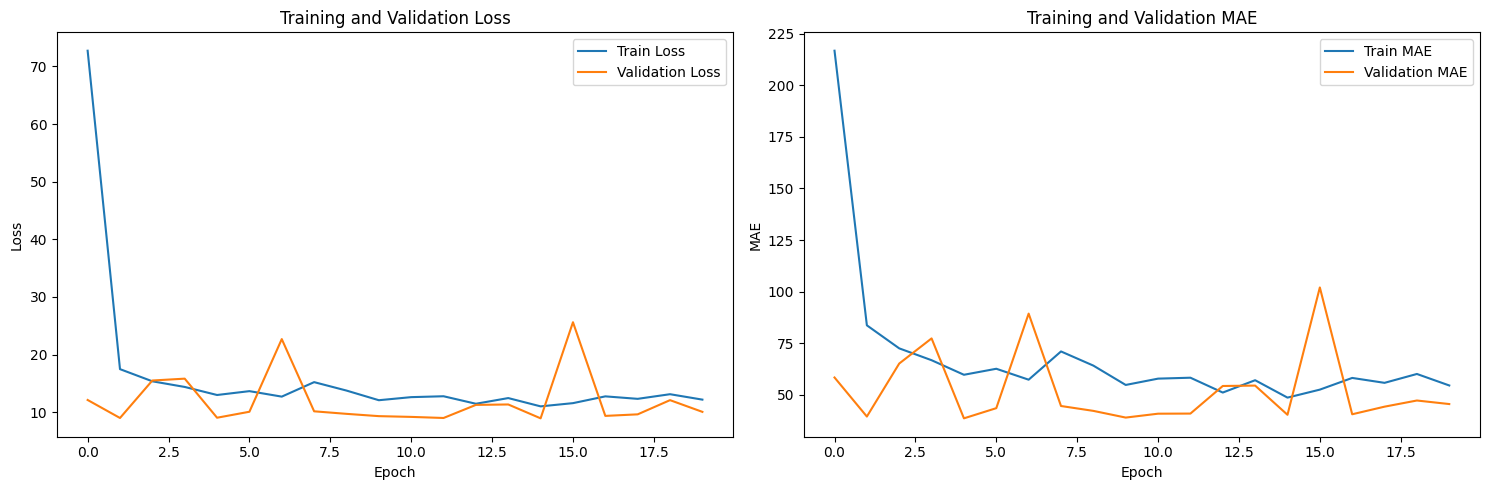

In [21]:
def plot_training_history(history, save_dir=config.RESULTS_DIR):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.set_title('Training and Validation Loss')
    
    ax2.plot(history['train_mae'], label='Train MAE')
    ax2.plot(history['val_mae'], label='Validation MAE')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.legend()
    ax2.set_title('Training and Validation MAE')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history)

# **EVALUATION**

In [22]:
# ==================== EVALUATION FUNCTIONS ====================
def evaluate_model(model, data_loader, device):
    model.eval()
    mae = mse = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for images, density_maps, counts, _ in data_loader:
            images, density_maps, counts = images.to(device), density_maps.to(device), counts.to(device)
            pred_density = model(images)
            pred_count = torch.sum(pred_density, dim=[1, 2, 3])
            
            mae += F.l1_loss(pred_count, counts).item()
            mse += F.mse_loss(pred_count, counts).item()
            all_preds.extend(pred_count.cpu().numpy())
            all_targets.extend(counts.cpu().numpy())
    
    return (mae/len(data_loader), np.sqrt(mse/len(data_loader)), 
            np.array(all_preds), np.array(all_targets))

In [23]:
# Evaluate on validation set
print("\nEvaluating on validation set...")
val_mae, val_rmse, val_preds, val_targets = evaluate_model(model, val_loader, device)
print(f"📊 Validation MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}")


Evaluating on validation set...
📊 Validation MAE: 45.4848, RMSE: 108.7453


In [24]:
# Evaluate on test set
print("\nEvaluating on test set...")
test_mae, test_rmse, test_preds, test_targets = evaluate_model(model, test_loader, device)
print(f"🧪 Test MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}")


Evaluating on test set...
🧪 Test MAE: 53.3744, RMSE: 150.2349


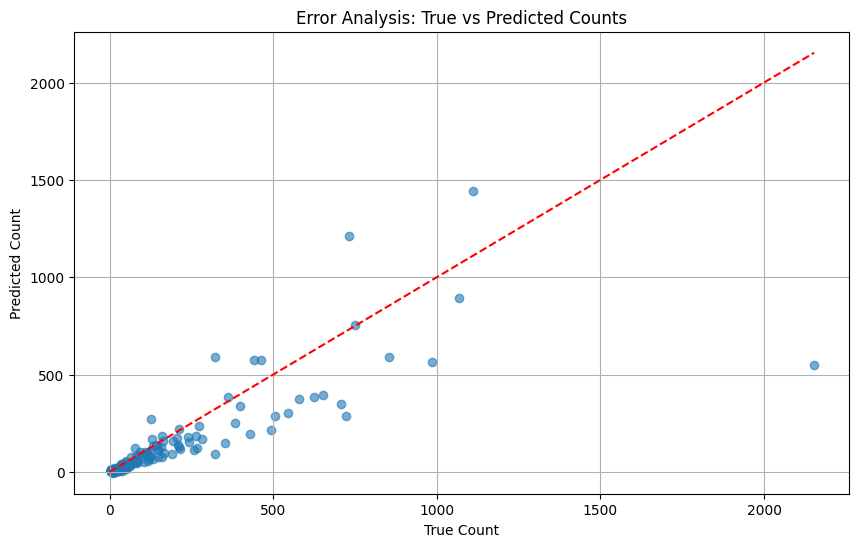

In [25]:
def plot_error_analysis(preds, targets, save_dir=config.RESULTS_DIR):
    plt.figure(figsize=(10, 6))
    plt.scatter(targets, preds, alpha=0.6)
    plt.plot([0, max(targets)], [0, max(targets)], 'r--')
    plt.xlabel('True Count')
    plt.ylabel('Predicted Count')
    plt.title('Error Analysis: True vs Predicted Counts')
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'error_analysis.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Error analysis
plot_error_analysis(test_preds, test_targets)

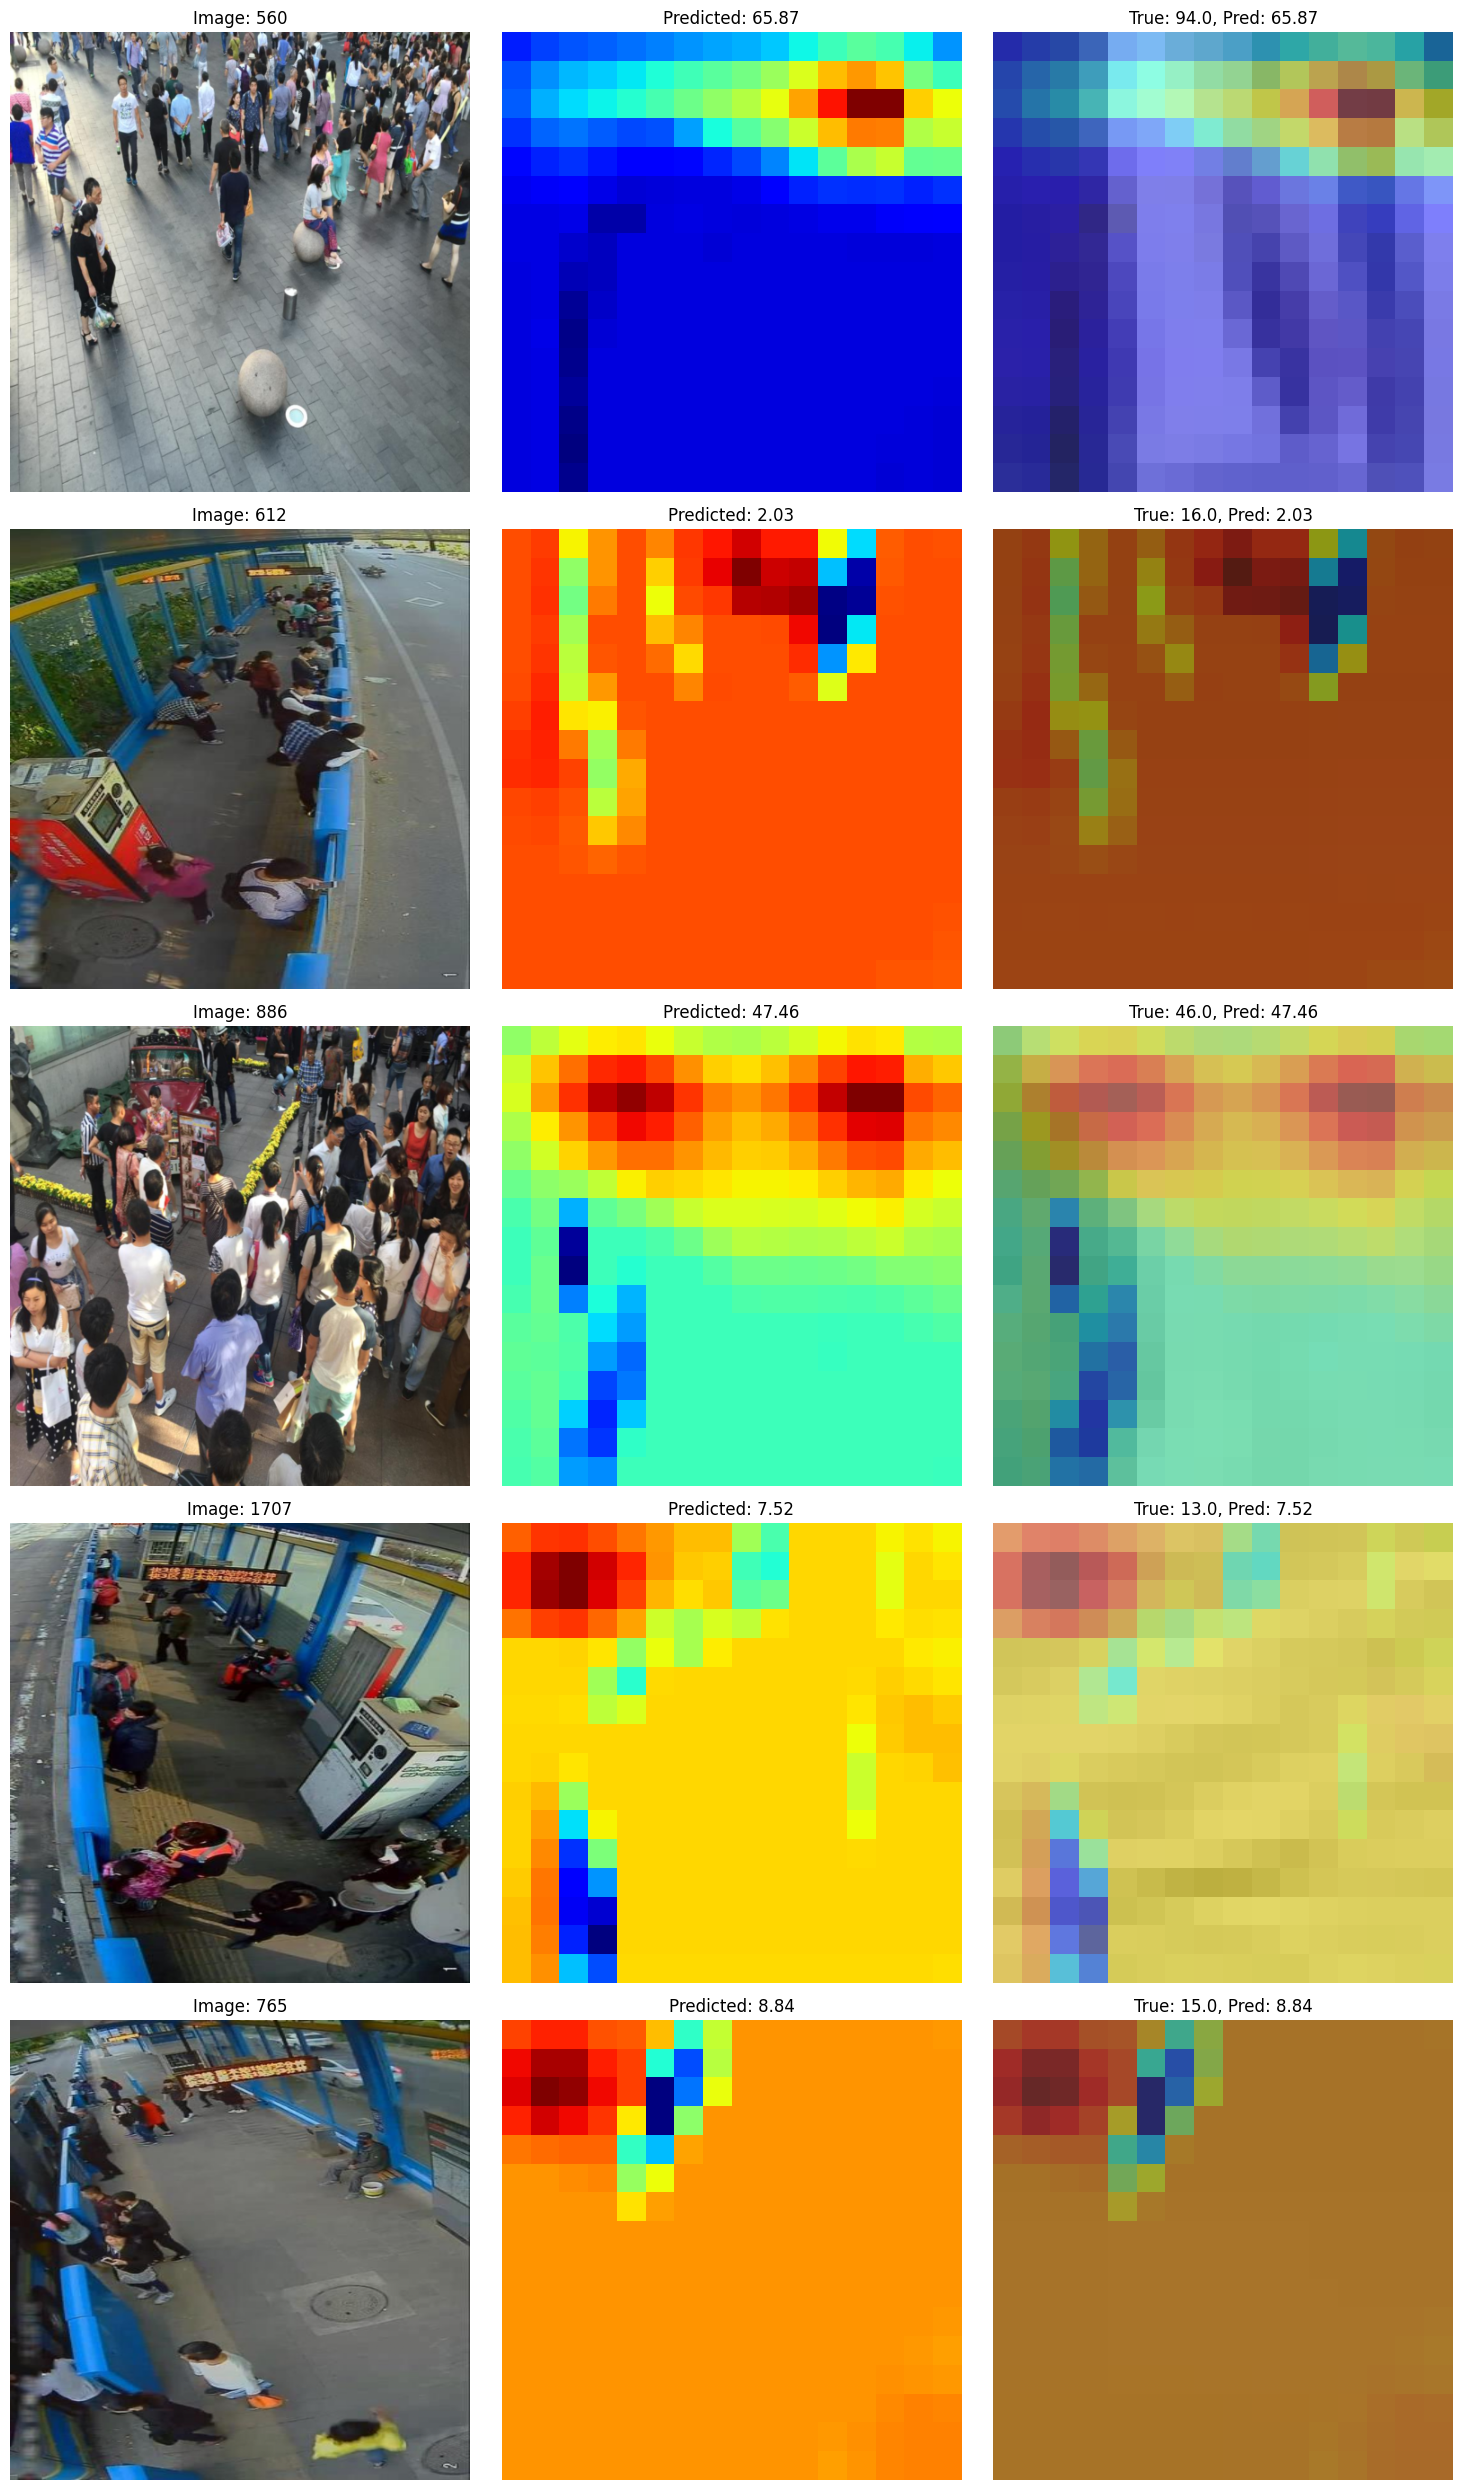

In [26]:
# ==================== VISUALIZATION FUNCTIONS ====================
def visualize_results(model, data_loader, device, num_samples=5, save_dir=config.RESULTS_DIR):
    model.eval()
    samples = []
    
    with torch.no_grad():
        for i, (images, density_maps, counts, img_ids) in enumerate(data_loader):
            if i >= num_samples: break
            images = images.to(device)
            pred_density = model(images)
            pred_count = torch.sum(pred_density, dim=[1, 2, 3])
            
            for j in range(min(images.size(0), num_samples-len(samples))):
                samples.append({
                    'image': images[j].cpu().permute(1, 2, 0).numpy(),
                    'pred_density': pred_density[j, 0].cpu().numpy(),
                    'true_count': counts[j].item(),
                    'pred_count': pred_count[j].item(),
                    'img_id': img_ids[j]
                })
    
    # Create visualization
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1: axes = axes.reshape(1, -1)
    
    for i, sample in enumerate(samples):
        axes[i, 0].imshow(sample['image'])
        axes[i, 0].set_title(f'Image: {sample["img_id"]}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(sample['pred_density'], cmap='jet')
        axes[i, 1].set_title(f'Predicted: {sample["pred_count"]:.2f}')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(sample['image'])
        axes[i, 2].imshow(sample['pred_density'], cmap='jet', alpha=0.5)
        axes[i, 2].set_title(f'True: {sample["true_count"]}, Pred: {sample["pred_count"]:.2f}')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Visualize results
visualize_results(model, test_loader, device)

# **Predicting on external test set**

In [27]:
def predict_test_set(model, test_loader, device):
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for images, img_ids in tqdm(test_loader, desc="Predicting test set"):
            images = images.to(device)
            pred_density = model(images)
            pred_count = torch.sum(pred_density, dim=[1, 2, 3])
            
            for i, img_id in enumerate(img_ids):
                predictions.append({
                    'image_id': img_id,
                    'prediction_count': max(0, pred_count[i].item())  # Ensure non-negative
                })
    
    return pd.DataFrame(predictions)

# Predict on external test set (500 images)
print("\n8. Predicting on external test set...")
external_test_dataset = TestDataset(config.TEST_IMAGE_DIR, transform=None)
external_test_loader = DataLoader(external_test_dataset, batch_size=config.BATCH_SIZE, 
                                 shuffle=False, collate_fn=test_collate, num_workers=2)

test_predictions = predict_test_set(model, external_test_loader, device)
print(f"✅ Predicted {len(test_predictions)} test images")

# Save predictions to CSV
test_predictions.to_csv(config.PREDICTIONS_CSV, index=False)
print(f"💾 Predictions saved to {config.PREDICTIONS_CSV}")

# Display sample predictions
print("\nSample predictions:")
print(test_predictions.head(10))


8. Predicting on external test set...


Predicting test set: 100%|██████████| 63/63 [00:05<00:00, 10.98it/s]

✅ Predicted 500 test images
💾 Predictions saved to /kaggle/working/test_predictions.csv

Sample predictions:
  image_id  prediction_count
0      208          5.394572
1      473        200.706177
2      333         24.554104
3       45         10.334290
4      369         63.636093
5       56         54.078941
6       89         63.620632
7       20          6.924621
8      275         80.316711
9      212         45.253426


# **Final Report**

In [29]:
# Save final report
report = f"""
Crowd Counting - Final Report
=========================================
Training Time: {training_time:.2f} seconds
Final Validation MAE: {val_mae:.4f}
Final Validation RMSE: {val_rmse:.4f}
Test Set MAE: {test_mae:.4f}
Test Set RMSE: {test_rmse:.4f}
Model Parameters: {sum(p.numel() for p in model.parameters()):,}
Training Samples: {len(train_subset)}
Validation Samples: {len(val_subset)}
Test Samples: {len(test_subset)}
External Test Predictions: {len(test_predictions)}
"""

with open(config.FINAL_REPORT_PATH, 'w') as f:
    f.write(report)

print(report)


Crowd Counting - Final Report
Training Time: 1029.13 seconds
Final Validation MAE: 45.4848
Final Validation RMSE: 108.7453
Test Set MAE: 53.3744
Test Set RMSE: 150.2349
Model Parameters: 31,053,057
Training Samples: 1329
Validation Samples: 380
Test Samples: 191
External Test Predictions: 500

